# Clustering & K-Means Algorithm

## What is Clustering?
- **Clustering** is an **unsupervised learning technique**.
- Goal: Group data points into clusters so that points in the same cluster are more similar to each other than to points in other clusters.
- It’s like organizing a messy wardrobe: shirts together, trousers together, shoes together, without anyone telling you the categories in advance.

### Key Idea
- No labels (like "Purchased=Yes/No").
- The algorithm discovers **patterns and groups** based only on the data features.

---

## What is K-Means?
- **K-Means** is one of the most popular clustering algorithms.
- It partitions the dataset into **K clusters** (where K is chosen by the user).
- Each cluster is represented by its **centroid** (the average position of points in that cluster).

---

## How K-Means Works Step by Step
1. **Choose K**  
   - Decide how many clusters you want (e.g., 2, 3, 4).
   - This is a hyperparameter you set before running the algorithm.

2. **Initialize Centroids**  
   - Randomly place K points in the data space as initial cluster centers.

3. **Assign Points to Clusters**  
   - Each data point is assigned to the nearest centroid (using distance, usually Euclidean).

4. **Update Centroids**  
   - For each cluster, calculate the mean of all points assigned to it.
   - Move the centroid to this new mean position.

5. **Repeat**  
   - Reassign points → update centroids → repeat until centroids stop moving significantly (convergence).

---

## What Type of Data Works Best?
- **Numeric, continuous features** (like Age, Salary, Height, Weight).
- K-Means relies on calculating distances, so categorical data (like Male/Female) needs to be encoded numerically first.
- Works well when clusters are roughly spherical and balanced in size.
- Not ideal for:
  - Highly skewed or overlapping clusters.
  - Data with outliers (they can pull centroids away).
  - Non-numeric features unless transformed.

---

## Key Insights
- K-Means is simple, fast, and widely used for customer segmentation, image compression, and pattern discovery.
- The choice of **K** is critical, too few clusters oversimplify, too many clusters overfit.
- Methods like the **Elbow Method** or **Silhouette Score** help decide the right K.
- The algorithm is sensitive to initial centroid placement, but techniques like **K-Means++** improve stability.

---

**Quick Note:**  
*K-Means is like finding the center of gravity for groups of points, assign, average, repeat, until the groups settle naturally.*


In [1]:
# Importing the libraries

import numpy as np              # For numerical operations, arrays, and handling mathematical computations
import matplotlib.pyplot as plt # For creating plots, graphs, and visualizing clusters or data distributions
import pandas as pd             # For loading datasets, handling tabular data, and performing data manipulation

In [2]:
# Importing the dataset
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

In [3]:
# Importing the dataset

# Load the dataset into a pandas DataFrame
# 'Mall_Customers.csv' contains customer details like CustomerID, Gender, Age, Annual Income, and Spending Score
dataset = pd.read_csv('Mall_Customers.csv')

# Selecting the features for clustering
# Here we take columns 3 and 4 → Annual Income and Spending Score
# These two features help us group customers based on income vs spending behavior
X = dataset.iloc[:, [3, 4]].values


# Elbow Method Explained

## What is the Elbow Method?
- K-Means requires us to choose the number of clusters (K).
- If we pick too few clusters → groups are too broad.
- If we pick too many clusters → groups are too fragmented.
- The **Elbow Method** helps us find the "sweet spot" for K.

---

## Formula Behind It
The key metric is **WCSS (Within-Cluster Sum of Squares)**:



\[
WCSS = \sum_{k=1}^{K} \sum_{i \in C_k} \| x_i - \mu_k \|^2
\]



Where:
- \(K\) = number of clusters  
- \(C_k\) = set of points in cluster \(k\)  
- \(x_i\) = data point  
- \(\mu_k\) = centroid of cluster \(k\)  
- \(\| x_i - \mu_k \|^2\) = squared Euclidean distance between point and centroid  

---

## Quick Note
1. For each cluster, calculate how far each point is from its centroid.  
2. Square those distances (to avoid negatives).  
3. Add them up → that’s the WCSS.  
4. Do this for different values of K (1, 2, 3 …).  
5. Plot WCSS vs K.  

he curve drops quickly at first, then flattens.  
The **bend (elbow)** is the point where adding more clusters doesn’t reduce WCSS much anymore — the optimal K.


# K-Means++ Initialization

## The Problem with Random Initialization
- Standard K-Means starts by picking **K random points** as centroids.
- If those points are too close together:
  - Clusters overlap or converge poorly.
  - The algorithm may take longer to stabilize.
  - Results can be unstable (different runs → different clusters).

---

## How K-Means++ Improves It
When we set `init='k-means++'`, scikit-learn uses a smarter way to choose starting centroids:

1. **Pick the first centroid randomly** from the dataset.
2. **For each next centroid:**
   - Calculate the distance of every point to the nearest chosen centroid.
   - Points that are **farther away** have a higher chance of being picked.
3. **Repeat until K centroids are chosen.**

This ensures centroids are **spread out across the dataset** instead of clumped together.

---

## Key Benefit
- Leads to **better clustering results**.
- Reduces the risk of poor convergence.
- Makes clusters more **stable and meaningful**.


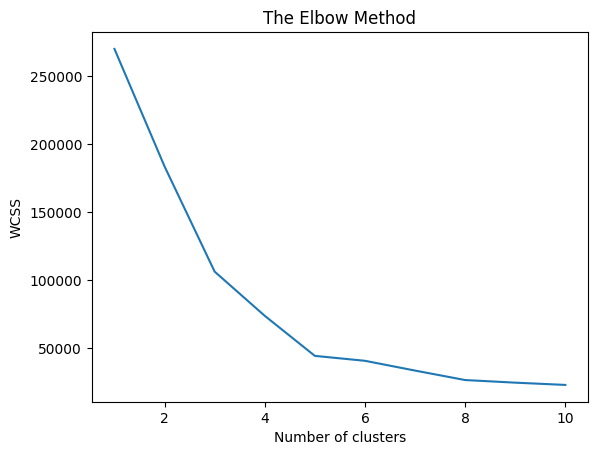

In [4]:
# Using the elbow method to find the optimal number of clusters

# Import KMeans from sklearn
from sklearn.cluster import KMeans

# Initialize an empty list to store WCSS (Within-Cluster Sum of Squares)
wcss = []

# Loop through possible cluster numbers (1 to 10)
for i in range(1, 11):
    # Create KMeans model with i clusters
    # init='k-means++' improves centroid initialization for better results
    # random_state ensures reproducibility
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    
    # Fit the model on the dataset
    kmeans.fit(X)
    
    # Append the inertia (WCSS) to the list
    # inertia_ = sum of squared distances of samples to their closest cluster center
    wcss.append(kmeans.inertia_)

# Plot the WCSS values against number of clusters
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')       # Title of the plot
plt.xlabel('Number of clusters')    # X-axis label
plt.ylabel('WCSS')                  # Y-axis label
plt.show()


# Elbow Method Analogy

Think of it like **buying buckets to carry water**:

- **1 bucket** → water spills everywhere (**high WCSS**).
- **2–3 buckets** → most water is contained (**big improvement**).
- **4+ buckets** → only tiny improvements, not worth the extra effort.

The **elbow** is the point where the curve bends — the right number of buckets to balance **effort vs benefit**.


# KMeans Parameters

### 1. `n_clusters`
- Number of clusters (K) you want to form.
- Example: `n_clusters=5` → the algorithm will group data into 5 clusters.
- Chosen using methods like **Elbow Method** or **Silhouette Score**.

---

### 2. `init`
- How the initial centroids are chosen.
- Options:
  - `'random'` → centroids picked randomly.
  - `'k-means++'` → smarter initialization that spreads centroids apart, reduces chances of poor clustering.
- Default: `'k-means++'`.

---

### 3. `n_init`
- Number of times the algorithm runs with different centroid seeds.
- The best result (lowest WCSS) is kept.
- Default: 10 (runs 10 times).

---

### 4. `max_iter`
- Maximum number of iterations for a single run.
- Each iteration = assign points → update centroids.
- Default: 300.

---

### 5. `random_state`
- Controls randomness for reproducibility.
- Example: `random_state=42` → ensures you get the same clusters every time you run.

---

### 6. `tol`
- Tolerance for convergence.
- If centroids move less than this value, the algorithm stops early.
- Default: 1e-4.

---

### 7. `algorithm`
- Which algorithm to use for computation.
- Options:
  - `'lloyd'` → standard K-Means.
  - `'elkan'` → faster for dense datasets with well-separated clusters.
- Default: `'lloyd'`.

---

# Key Takeaway
- **Most important parameters**: `n_clusters`, `init`, `random_state`.  
- Others (`n_init`, `max_iter`, `tol`) control performance and convergence.  
- Choosing the right **K** is critical, parameters just fine-tune how clustering is done.


#  K-Means++

## The Problem with Random Start
- In normal K-Means, the first cluster centers (centroids) are picked randomly.
- If those starting points are too close together, the algorithm may form poor clusters or take longer to adjust.

---

## The Smart Idea of K-Means++
- K-Means++ improves this by **spreading out the starting centroids**.
- Steps:
  1. Pick the first centroid randomly.
  2. For the next centroid, look at all points and measure their distance from the already chosen centroid.
  3. Points that are **farther away** have a higher chance of being picked as the next centroid.
  4. Repeat until all K centroids are chosen.

---

## Why It’s Better
- Centroids start in **different regions** of the data.
- Clusters form more naturally and quickly.
- Results are more stable compared to random initialization.

---

## Easy Analogy
Imagine you’re opening **5 new shops in a city**:
- Random choice → you might accidentally place 3 shops on the same street.
- K-Means++ → you spread shops across different neighborhoods, so each shop serves a unique area.


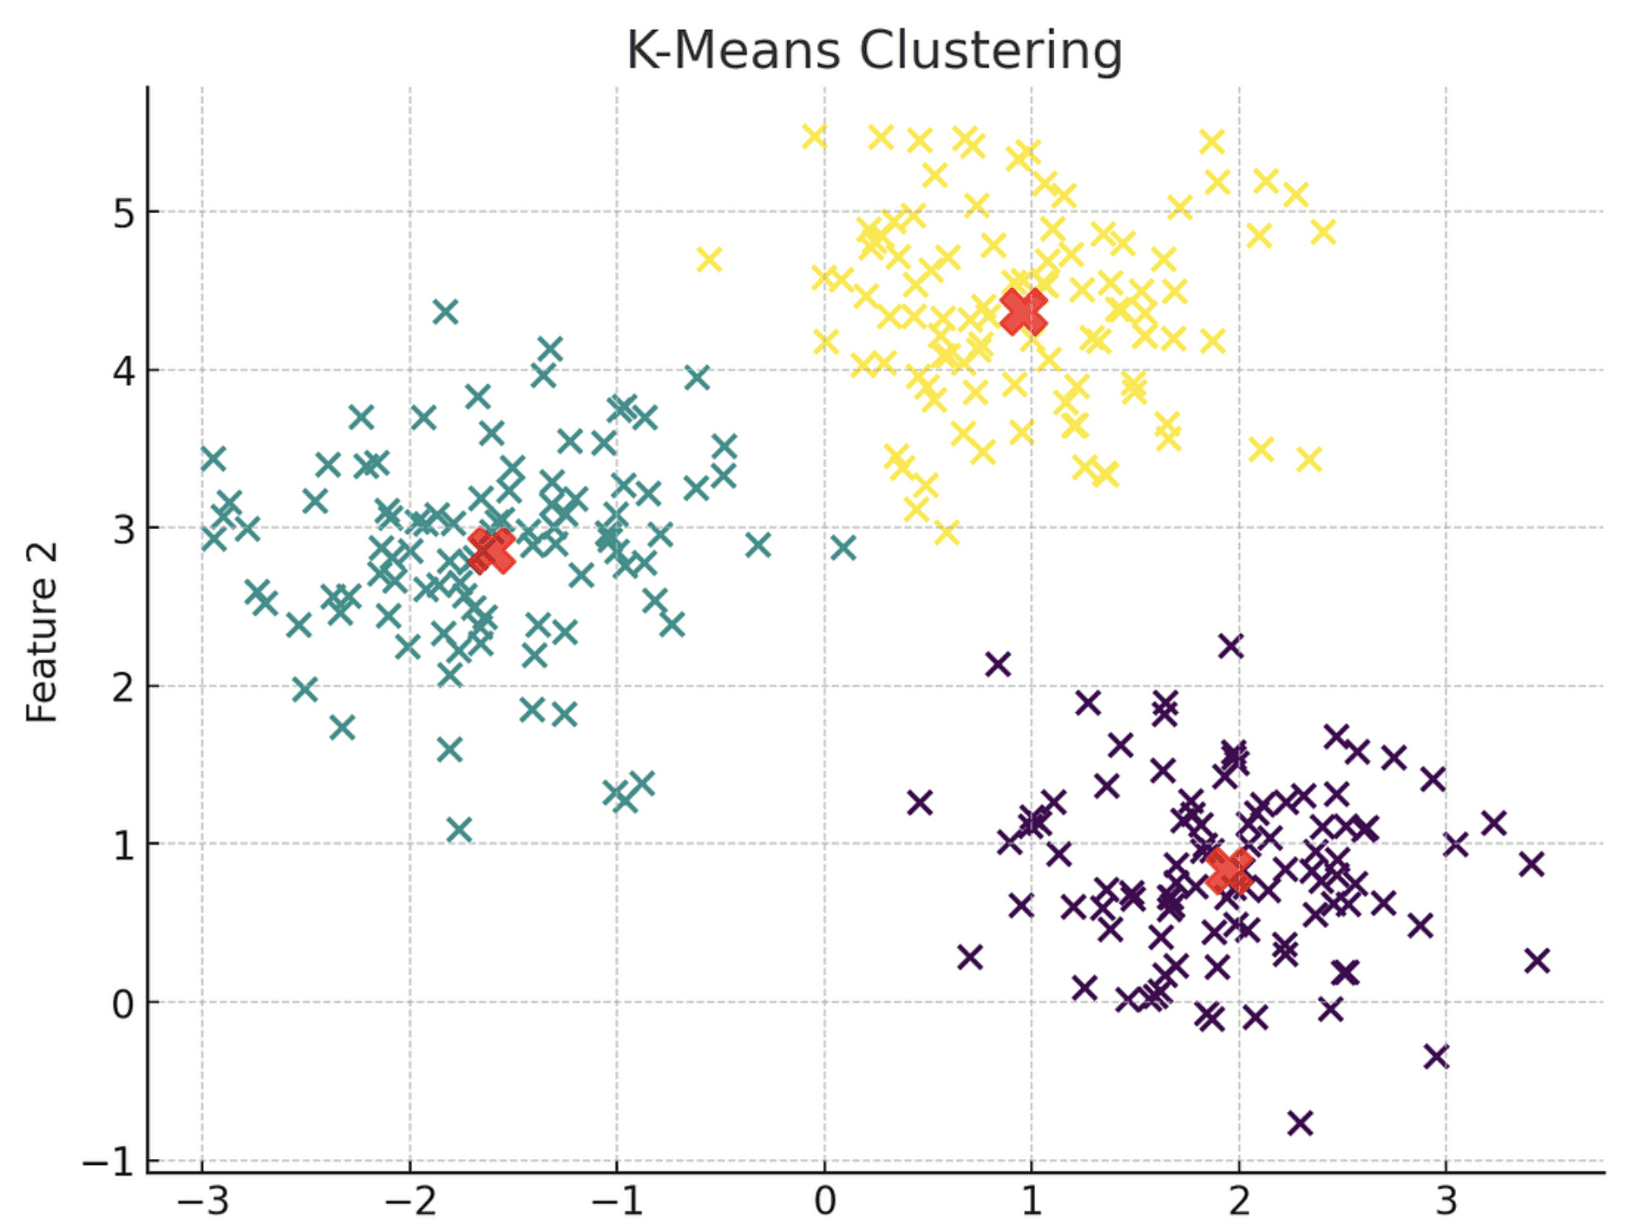

In [12]:
from IPython.display import Image, display
# Show the image directly
display(Image(filename="clustering.png"))   # replace with your filename

In [ ]:
# Training the K-Means model on the dataset

# Create the KMeans model with 5 clusters (based on elbow method result)
# init='k-means++' ensures better centroid initialization
# random_state=42 makes results reproducible
kmeans = KMeans(n_clusters= 5,init='k-means++', random_state=42)

# Fit the model on the dataset and predict cluster assignments
# y_kmeans will contain the cluster index (0–4) for each data point
y_kmeans = kmeans.fit_predict(X)

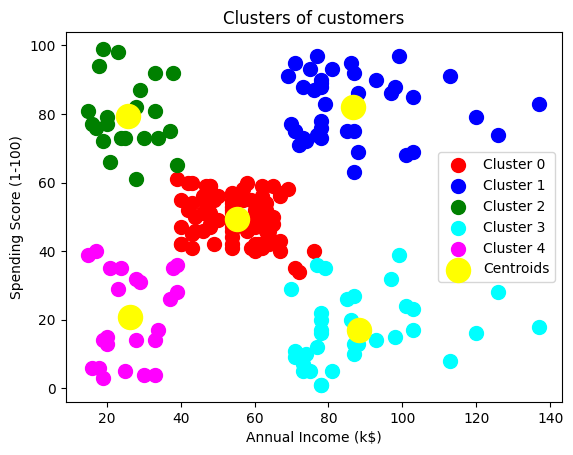

In [8]:
# Visualising the clusters

# Plot each cluster with a different color and label (matching sklearn indices)
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], 
            s=100, c='red', label='Cluster 0')       # Cluster index 0
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], 
            s=100, c='blue', label='Cluster 1')      # Cluster index 1
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], 
            s=100, c='green', label='Cluster 2')     # Cluster index 2
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], 
            s=100, c='cyan', label='Cluster 3')      # Cluster index 3
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], 
            s=100, c='magenta', label='Cluster 4')   # Cluster index 4

# Plot the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='yellow', label='Centroids')

# Add plot details
plt.title('Clusters of customers')                   # Title of the plot
plt.xlabel('Annual Income (k$)')                     # X-axis label
plt.ylabel('Spending Score (1-100)')                 # Y-axis label
plt.legend()                                         # Show legend
plt.show()                                           # Display the plot

In [9]:
# Predict cluster for new data point
new_customer = np.array([[40, 60]])   # Annual Income=40k, Spending Score=60
cluster_id = kmeans.predict(new_customer)
print("This customer belongs to Cluster:", cluster_id)

This customer belongs to Cluster: [0]


## Interpreting K-Means Predictions

### What does `.predict()` return?
- In K-Means, `.predict()` gives the **cluster index** (0, 1, 2, …).
- Example: `[0]` means the new data point belongs to **Cluster 0**.
- These numbers are **IDs**, not ranks, Cluster 0 is not "better" than Cluster 4, it’s just the first group formed.

---

####  How to interpret Cluster 0
1. **Check the centroid**:  
   - `kmeans.cluster_centers_[0]` → gives the average Annual Income and Spending Score of Cluster 0.
   - This tells us the **profile** of customers in that group.

2. **Make assumptions**:  
   - New customers in Cluster 0 will likely behave like others in that group.
   - Example: If Cluster 0 = *low income, low spending*, then this new customer is expected to be a budget shopper.

3. **Business action**:  
   - If Cluster 0 = low income, low spending → target with discounts, loyalty programs.
   - If Cluster 0 = high income, high spending → target with premium products, exclusive offers.
   - If Cluster 0 = high income, low spending → focus on engagement strategies to increase spending.

---

### Key Takeaway
- **Prediction in K-Means = cluster assignment.**
- The real value comes from **interpreting what each cluster represents** and then designing strategies for those customer groups.


# Top Questions on Clustering & K-Means

---

## 1. What is clustering?
Clustering is an **unsupervised learning technique** that groups data points into clusters such that points in the same cluster are more similar to each other than to points in other clusters.

---

## 2. What is K-Means clustering?
K-Means is a popular clustering algorithm that:
1. Chooses **K centroids**.
2. Assigns each point to the nearest centroid (forming clusters).
3. Updates centroids as the mean of points in each cluster.
4. Repeats until centroids stabilize.

---

## 3. Why do we use the Elbow Method?
The Elbow Method helps decide the **optimal number of clusters (K)** by plotting WCSS (Within-Cluster Sum of Squares) vs K.  
The "elbow point" is where adding more clusters doesn’t significantly reduce WCSS.

---

## 4. What distance metric does K-Means use?
By default, K-Means uses **Euclidean distance** to measure closeness between points and centroids.

---

## 5. What is WCSS (Within-Cluster Sum of Squares)?
WCSS is the sum of squared distances between each point and its cluster centroid.  
Lower WCSS means tighter clusters.

---

## 6. What is the role of `init='k-means++'`?
- Standard K-Means may pick centroids too close together → poor results.  
- K-Means++ spreads centroids apart during initialization → better convergence and more stable clusters.

---

## 7. What are the limitations of K-Means?
- Requires specifying **K** in advance.  
- Sensitive to **outliers**.  
- Works best with **spherical clusters** (not irregular shapes).  
- Assumes clusters of similar size.

---

## 8. How do we interpret clusters in business terms?
- Each cluster represents a **customer segment** (e.g., budget shoppers, premium spenders).  
- Businesses can use these segments for **targeted ads, offers, and engagement strategies**.

---

## 9. What happens if we include more features (like Age)?
- Clustering moves from 2D (Income vs Spending Score) to higher dimensions (Age, Income, Spending Score).  
- More features can give richer segmentation but may require **scaling** to avoid bias from large numerical ranges.

---

## 10. How do we evaluate clustering quality?
Common methods:
- **Silhouette Score** → measures how well points fit within their cluster vs other clusters.  
- **Davies-Bouldin Index** → lower values indicate better clustering.  
- **Visual inspection** (scatter plots, PCA reduction).